# 01 - Meta-Learners

Benchmark of six meta-learner recipes - S / T / X / R / DR (causalml) and DA (econml) - each run with two base learners, LightGBM and CatBoost, on a 500K-row sample. Base-learner hyperparameters are fixed across recipes (tuning is notebook 05). Evaluation on a stratified 20% hold-out: AUUC, Qini, Uplift@10%, Uplift@20% - see [METRICS.md](METRICS.md).

## Setup

`causalml` has no domain-adaptation meta-learner (its `meta` module exposes only S/T/X/R/DR and TMLE); DA comes from `econml.metalearners.DomainAdaptationLearner`, which uses regressors on the 0/1 outcome and a different API: `.fit(Y, T, X=...)` / `.effect(X)`.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from criteo_data import fetch_criteo
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k, qini_curve

# causalml meta-learners
from causalml.inference.meta import (
    BaseSClassifier,
    BaseTClassifier,
    BaseXClassifier,
    BaseRClassifier,
    BaseDRLearner,
)

# DA-Learner (Domain Adaptation): causalml has no domain-adaptation meta-learner.
# The real implementation is econml's DomainAdaptationLearner - a T-Learner
# variant that reweights each arm's outcome model toward the other arm's
# covariate distribution.
from econml.metalearners import DomainAdaptationLearner

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
SAMPLE_SIZE = 500_000  # set to None for full dataset

## Load & split data

The split is stratified on the four (treatment × conversion) cells: control converters are the scarcest at roughly `15% × ~0.2% ≈ 0.03%` of rows (a few hundred at 500K), and a plain random split could unbalance them enough to swamp the metrics.

In [2]:
print('Loading Criteo dataset...')
dataset = fetch_criteo(target_col='conversion')
X_full, y_full, treat_full = dataset.data, dataset.target, dataset.treatment

# Re-seed right before the draw so this cell reproduces the same 500K
# subsample as notebooks 02-06 (which all seed then choose in one cell). The
# cross-notebook leaderboard comparison depends on an identical test set.
np.random.seed(SEED)
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), SAMPLE_SIZE, replace=False)
    X_full = X_full.iloc[idx].reset_index(drop=True)
    y_full = y_full.iloc[idx].reset_index(drop=True)
    treat_full = treat_full.iloc[idx].reset_index(drop=True)

print(f'Working dataset: {len(X_full):,} rows')

Loading Criteo dataset...


Working dataset: 500,000 rows


In [3]:
# Stratified split - preserve rare (treatment=1, conversion=1) cells
strat_key = treat_full.values * 2 + y_full.values

(
    X_train, X_test,
    y_train, y_test,
    treat_train, treat_test
) = train_test_split(
    X_full.values, y_full.values, treat_full.values,
    test_size=0.2, random_state=SEED, stratify=strat_key
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Treatment share - train: {treat_train.mean():.3f}  test: {treat_test.mean():.3f}')
print(f'Conversion rate - train: {y_train.mean():.5f}  test: {y_test.mean():.5f}')

Train: 400,000  |  Test: 100,000
Treatment share - train: 0.850  test: 0.850
Conversion rate - train: 0.00307  test: 0.00306


## Shared utilities

Base-learner hyperparameters are fixed across recipes so the comparison is recipe vs recipe; `min_child_samples=50` guards LightGBM against overfitting the rare positives. A non-uplift **outcome-rank baseline** (rank by predicted $P(Y=1 \mid X)$, ignoring $T$) is scored with the same metrics - beating it is the premise of uplift modeling. `CatBoostRegressorDA` remaps CatBoost's third positional `fit` argument back to `sample_weight`, which econml's `DomainAdaptationLearner` passes positionally.

In [4]:
FEATURE_NAMES = X_full.columns.tolist()

LGBM_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

# CatBoost notes vs LightGBM on this dataset:
#   + ordered boosting reduces a target-leakage bias present in ordinary boosting
#   + symmetric (oblivious) trees → faster, more predictable inference
#   + probability calibration is generally closer to truth out of the box
#   - no num_leaves (symmetric tree architecture)
#   - slower per iteration than LGBM on large datasets
#   - native-categorical advantage does not apply - all features are continuous
CATBOOST_PARAMS = dict(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_seed=SEED,
    thread_count=-1,
    verbose=0,
)


# econml's DomainAdaptationLearner passes sample_weight as the third positional
# argument to fit(). For CatBoost that position is `cat_features`, so the plain
# regressor raises. This subclass remaps the third positional back to
# sample_weight. (LightGBM needs no wrapper: its third positional already is
# sample_weight.)
class CatBoostRegressorDA(CatBoostRegressor):
    def fit(self, X, y=None, sample_weight=None, **kwargs):
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

results = {}     # {model_name: {metric: value}}
qini_curves = {} # {model_name: uplift_scores}


def evaluate(name: str, uplift_scores: np.ndarray, elapsed: float) -> dict:
    scores = uplift_scores.flatten()
    row = {
        'AUUC':       round(uplift_auc_score(y_test, scores, treat_test), 6),
        'Qini':       round(qini_auc_score(y_test, scores, treat_test),   6),
        'Uplift@10%': round(uplift_at_k(y_test, scores, treat_test, strategy='by_group', k=0.1), 4),
        'Uplift@20%': round(uplift_at_k(y_test, scores, treat_test, strategy='by_group', k=0.2), 4),
        'Time(s)':    round(elapsed, 1),
    }
    results[name] = row
    qini_curves[name] = scores
    print(f'[{name:<22}]  Qini={row["Qini"]:.6f}  '
          f'@10%={row["Uplift@10%"]:.4f}  @20%={row["Uplift@20%"]:.4f}  '
          f'time={row["Time(s)"]}s')
    return row


print('Utilities ready.')

Utilities ready.


In [5]:
# Non-uplift baseline: rank users by predicted RESPONSE P(Y=1|X), ignoring T.
# Beating this response-model ranking is the entire premise of uplift modeling -
# if a CATE model can't, that is a finding worth reporting. Saved into the artifact
# so it appears in the 06 leaderboard alongside the random baseline.
t0 = time.time()
resp_model = LGBMClassifier(**LGBM_PARAMS).fit(X_train, y_train)
evaluate('Outcome-rank baseline', resp_model.predict_proba(X_test)[:, 1], time.time() - t0)

[Outcome-rank baseline ]  Qini=0.208940  @10%=0.0124  @20%=0.0061  time=2.7s


{'AUUC': 0.007051,
 'Qini': 0.20894,
 'Uplift@10%': 0.0124,
 'Uplift@20%': 0.0061,
 'Time(s)': 2.7}

---
## LightGBM Base Learner

All six recipes with LightGBM; the CatBoost sweep follows as a base-learner sensitivity check.

### S-Learner (LightGBM)

One model $\hat m(x, t)$ with $T$ as a feature; $\hat\tau_S(x) = \hat m(x, 1) - \hat m(x, 0)$. With a tiny ATE, tree regularization can shrink the influence of $T$ toward zero - check that $\hat\tau$ has non-zero variance.

In [6]:
t0 = time.time()
s_lgbm = BaseSClassifier(learner=LGBMClassifier(**LGBM_PARAMS))
s_lgbm.fit(X=X_train, treatment=treat_train, y=y_train)
evaluate('S-Learner (LGBM)', s_lgbm.predict(X=X_test, treatment=treat_test), time.time() - t0)

[S-Learner (LGBM)      ]  Qini=0.143432  @10%=0.0113  @20%=0.0056  time=3.1s


{'AUUC': 0.004828,
 'Qini': 0.143432,
 'Uplift@10%': 0.0113,
 'Uplift@20%': 0.0056,
 'Time(s)': 3.1}

### T-Learner (LightGBM)

One outcome model per arm; $\hat\tau_T(x) = \hat m_1(x) - \hat m_0(x)$. Arm variances add, and the ~15% control arm makes $\hat m_0$ the noisy one.

In [7]:
t0 = time.time()
t_lgbm = BaseTClassifier(learner=LGBMClassifier(**LGBM_PARAMS))
t_lgbm.fit(X=X_train, treatment=treat_train, y=y_train)
evaluate('T-Learner (LGBM)', t_lgbm.predict(X=X_test), time.time() - t0)

[T-Learner (LGBM)      ]  Qini=0.190324  @10%=0.0131  @20%=0.0060  time=4.4s


{'AUUC': 0.006416,
 'Qini': 0.190324,
 'Uplift@10%': 0.0131,
 'Uplift@20%': 0.006,
 'Time(s)': 4.4}

### X-Learner (LightGBM)

Two-stage cross-imputation (Künzel et al. 2019): impute each arm's counterfactual with the other arm's outcome model, fit CATE regressors on the pseudo-effects, combine with propensity weights. Built for unbalanced arms; at 85/15 the imbalance is mild, so expect at most a modest gain over T.

In [8]:
t0 = time.time()
x_lgbm = BaseXClassifier(
    outcome_learner=LGBMClassifier(**LGBM_PARAMS),
    effect_learner=LGBMRegressor(**LGBM_PARAMS),
)
x_lgbm.fit(X=X_train, treatment=treat_train, y=y_train)
evaluate('X-Learner (LGBM)', x_lgbm.predict(X=X_test), time.time() - t0)

[X-Learner (LGBM)      ]  Qini=0.111613  @10%=0.0093  @20%=0.0045  time=358.7s


{'AUUC': 0.00377,
 'Qini': 0.111613,
 'Uplift@10%': 0.0093,
 'Uplift@20%': 0.0045,
 'Time(s)': 358.7}

### R-Learner (LightGBM)

Residual-on-residual regression (Nie & Wager 2021): fit $\tau$ by the R-loss on $Y - \hat m(X)$ and $T - \hat e(X)$. The RCT propensity is known and constant, so `p = treat_train.mean()` is passed directly - letting causalml fit an in-sample propensity would overfit away from the constant and distort the $(T - \hat e)$ weights.

In [9]:
t0 = time.time()
# RCT propensity is known and (near-)constant, so pass it directly. Letting
# causalml fit a flexible in-sample LGBM propensity (no cross-fitting) would
# overfit away from the true constant and distort the R-loss (T - e) weights.
p_rct = np.full(len(y_train), treat_train.mean())
r_lgbm = BaseRClassifier(
    outcome_learner=LGBMClassifier(**LGBM_PARAMS),
    effect_learner=LGBMRegressor(**LGBM_PARAMS),
    random_state=SEED,
)
r_lgbm.fit(X=X_train, treatment=treat_train, y=y_train, p=p_rct)
evaluate('R-Learner (LGBM)', r_lgbm.predict(X=X_test), time.time() - t0)

/Users/ilia.ekhlakov/Projects/Criteo_Uplifts/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/ilia.ekhlakov/Projects/Criteo_Uplifts/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ilia.ekhlakov/Projects/Criteo_Uplifts/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/ilia.ekhlakov/Projects/Criteo_Uplifts/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ilia.ekhlakov/Projects/Criteo_Uplifts/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[R-Learner (LGBM)      ]  Qini=0.139630  @10%=0.0101  @20%=0.0047  time=13.3s


{'AUUC': 0.004703,
 'Qini': 0.13963,
 'Uplift@10%': 0.0101,
 'Uplift@20%': 0.0047,
 'Time(s)': 13.3}

### DR-Learner (LightGBM)

Regress the doubly robust (AIPW) pseudo-outcome on $X$ (Kennedy 2023): consistent if either the outcome models or the propensity is correctly specified. `BaseDRLearner` cross-fits internally (default `cv=3`); `seed=SEED` fixes the folds. With rare outcomes the pseudo-outcome is high-variance, so propensity clipping to [0.01, 0.99] is essential.

In [10]:
t0 = time.time()
dr_lgbm = BaseDRLearner(
    learner=LGBMRegressor(**LGBM_PARAMS),
    treatment_effect_learner=LGBMRegressor(**LGBM_PARAMS),
)
# seed= fixes the internal cross-fitting folds so the result is reproducible.
dr_lgbm.fit(X=X_train, treatment=treat_train, y=y_train, seed=SEED)
evaluate('DR-Learner (LGBM)', dr_lgbm.predict(X=X_test), time.time() - t0)

[DR-Learner (LGBM)     ]  Qini=0.253319  @10%=0.0132  @20%=0.0067  time=208.6s


{'AUUC': 0.008547,
 'Qini': 0.253319,
 'Uplift@10%': 0.0132,
 'Uplift@20%': 0.0067,
 'Time(s)': 208.6}

### DA-Learner (LightGBM)

T-Learner variant that reweights each arm's training rows toward the other arm's covariate distribution - a covariate-shift correction, heuristic, no asymptotic guarantee. In a clean RCT the arms share one distribution, so the reweighting is near a no-op and DA should track the T-Learner.

In [11]:
# econml's DomainAdaptationLearner uses regressors on the 0/1 outcome and its own
# .fit(Y, T, X=) / .effect(X) API (different from the causalml learners above).
t0 = time.time()
da_lgbm = DomainAdaptationLearner(
    models=LGBMRegressor(**LGBM_PARAMS),
    final_models=LGBMRegressor(**LGBM_PARAMS),
)
da_lgbm.fit(y_train, treat_train, X=X_train)
evaluate('DA-Learner (LGBM)', da_lgbm.effect(X_test), time.time() - t0)

[DA-Learner (LGBM)     ]  Qini=0.057724  @10%=0.0085  @20%=0.0041  time=6.2s


{'AUUC': 0.001944,
 'Qini': 0.057724,
 'Uplift@10%': 0.0085,
 'Uplift@20%': 0.0041,
 'Time(s)': 6.2}

---
## CatBoost Base Learner

Same six recipes with CatBoost: does the meta-learner ranking depend on the base learner, and do CatBoost's typically better-calibrated probabilities help the nuisance-sensitive recipes (R, DR)?

### S-Learner (CatBoost)

In [12]:
t0 = time.time()
s_cb = BaseSClassifier(learner=CatBoostClassifier(**CATBOOST_PARAMS))
s_cb.fit(X=X_train, treatment=treat_train, y=y_train)
evaluate('S-Learner (CB)', s_cb.predict(X=X_test, treatment=treat_test), time.time() - t0)

[S-Learner (CB)        ]  Qini=0.161378  @10%=0.0098  @20%=0.0058  time=4.5s


{'AUUC': 0.005437,
 'Qini': 0.161378,
 'Uplift@10%': 0.0098,
 'Uplift@20%': 0.0058,
 'Time(s)': 4.5}

### T-Learner (CatBoost)

In [13]:
t0 = time.time()
t_cb = BaseTClassifier(learner=CatBoostClassifier(**CATBOOST_PARAMS))
t_cb.fit(X=X_train, treatment=treat_train, y=y_train)
evaluate('T-Learner (CB)', t_cb.predict(X=X_test), time.time() - t0)

[T-Learner (CB)        ]  Qini=0.131089  @10%=0.0101  @20%=0.0052  time=5.4s


{'AUUC': 0.004404,
 'Qini': 0.131089,
 'Uplift@10%': 0.0101,
 'Uplift@20%': 0.0052,
 'Time(s)': 5.4}

### X-Learner (CatBoost)

In [14]:
t0 = time.time()
x_cb = BaseXClassifier(
    outcome_learner=CatBoostClassifier(**CATBOOST_PARAMS),
    effect_learner=CatBoostRegressor(**CATBOOST_PARAMS),
)
x_cb.fit(X=X_train, treatment=treat_train, y=y_train)
evaluate('X-Learner (CB)', x_cb.predict(X=X_test), time.time() - t0)

[X-Learner (CB)        ]  Qini=0.127480  @10%=0.0101  @20%=0.0047  time=374.5s


{'AUUC': 0.004284,
 'Qini': 0.12748,
 'Uplift@10%': 0.0101,
 'Uplift@20%': 0.0047,
 'Time(s)': 374.5}

### R-Learner (CatBoost)

In [15]:
t0 = time.time()
p_rct = np.full(len(y_train), treat_train.mean())
r_cb = BaseRClassifier(
    outcome_learner=CatBoostClassifier(**CATBOOST_PARAMS),
    effect_learner=CatBoostRegressor(**CATBOOST_PARAMS),
    random_state=SEED,
)
r_cb.fit(X=X_train, treatment=treat_train, y=y_train, p=p_rct)
evaluate('R-Learner (CB)', r_cb.predict(X=X_test), time.time() - t0)

[R-Learner (CB)        ]  Qini=0.240742  @10%=0.0133  @20%=0.0065  time=16.6s


{'AUUC': 0.008119,
 'Qini': 0.240742,
 'Uplift@10%': 0.0133,
 'Uplift@20%': 0.0065,
 'Time(s)': 16.6}

### DR-Learner (CatBoost)

In [16]:
t0 = time.time()
dr_cb = BaseDRLearner(
    learner=CatBoostRegressor(**CATBOOST_PARAMS),
    treatment_effect_learner=CatBoostRegressor(**CATBOOST_PARAMS),
)
dr_cb.fit(X=X_train, treatment=treat_train, y=y_train, seed=SEED)
evaluate('DR-Learner (CB)', dr_cb.predict(X=X_test), time.time() - t0)

[DR-Learner (CB)       ]  Qini=0.186780  @10%=0.0115  @20%=0.0054  time=302.7s


{'AUUC': 0.006293,
 'Qini': 0.18678,
 'Uplift@10%': 0.0115,
 'Uplift@20%': 0.0054,
 'Time(s)': 302.7}

### DA-Learner (CatBoost)

In [17]:
t0 = time.time()
da_cb = DomainAdaptationLearner(
    models=CatBoostRegressorDA(**CATBOOST_PARAMS),
    final_models=CatBoostRegressorDA(**CATBOOST_PARAMS),
)
da_cb.fit(y_train, treat_train, X=X_train)
evaluate('DA-Learner (CB)', da_cb.effect(X_test), time.time() - t0)

[DA-Learner (CB)       ]  Qini=0.024670  @10%=0.0059  @20%=0.0032  time=25.6s


{'AUUC': 0.000815,
 'Qini': 0.02467,
 'Uplift@10%': 0.0059,
 'Uplift@20%': 0.0032,
 'Time(s)': 25.6}

---
## Results comparison

All (recipe × base learner) results in one table, sorted by Qini - the project's primary ranking metric. Uplift@10% / @20% are sklift's absolute top-k rate differences $\bar Y_{T=1} - \bar Y_{T=0}$ (see [METRICS.md §1.3](METRICS.md)). Caveat: with a small ATE and only ~15% control in a 100K-row test set, Qini values cluster in a narrow band and their sampling error is non-trivial - the bootstrap in [06_benchmark.ipynb](06_benchmark.ipynb) puts the per-model Qini standard error around 0.03-0.07 on the normalized scale and reports pairwise-delta tiers. Trust those over any single-split point estimate here.

In [18]:
df_results = pd.DataFrame(results).T.astype(float)
df_results = df_results.sort_values('Qini', ascending=False)

# Tag base learner for grouped display
df_results['Base'] = df_results.index.map(
    lambda n: 'CatBoost' if '(CB)' in n else 'LightGBM'
)

print('\n=== Meta-Learner Benchmark (hold-out 20%) ===')
print(df_results.drop(columns='Base').to_string(
    float_format=lambda x: f'{x:.6f}' if abs(x) < 10 else f'{x:.1f}'
))


=== Meta-Learner Benchmark (hold-out 20%) ===
                          AUUC     Qini  Uplift@10%  Uplift@20%  Time(s)
DR-Learner (LGBM)     0.008547 0.253319    0.013200    0.006700    208.6
R-Learner (CB)        0.008119 0.240742    0.013300    0.006500     16.6
Outcome-rank baseline 0.007051 0.208940    0.012400    0.006100 2.700000
T-Learner (LGBM)      0.006416 0.190324    0.013100    0.006000 4.400000
DR-Learner (CB)       0.006293 0.186780    0.011500    0.005400    302.7
S-Learner (CB)        0.005437 0.161378    0.009800    0.005800 4.500000
S-Learner (LGBM)      0.004828 0.143432    0.011300    0.005600 3.100000
R-Learner (LGBM)      0.004703 0.139630    0.010100    0.004700     13.3
T-Learner (CB)        0.004404 0.131089    0.010100    0.005200 5.400000
X-Learner (CB)        0.004284 0.127480    0.010100    0.004700    374.5
X-Learner (LGBM)      0.003770 0.111613    0.009300    0.004500    358.7
DA-Learner (LGBM)     0.001944 0.057724    0.008500    0.004100 6.200000
DA-L

In [19]:
df_results.drop(columns='Base').style \
    .background_gradient(subset=['AUUC', 'Qini', 'Uplift@10%', 'Uplift@20%'], cmap='Greens') \
    .background_gradient(subset=['Time(s)'], cmap='Reds_r') \
    .format({
        'AUUC': '{:.6f}', 'Qini': '{:.6f}',
        'Uplift@10%': '{:.4f}', 'Uplift@20%': '{:.4f}', 'Time(s)': '{:.1f}'
    })

,AUUC,Qini,Uplift@10%,Uplift@20%,Time(s)
DR-Learner (LGBM),0.008547,0.253319,0.0132,0.0067,208.6
R-Learner (CB),0.008119,0.240742,0.0133,0.0065,16.6
Outcome-rank baseline,0.007051,0.208940,0.0124,0.0061,2.7
T-Learner (LGBM),0.006416,0.190324,0.0131,0.0060,4.4
DR-Learner (CB),0.006293,0.186780,0.0115,0.0054,302.7
S-Learner (CB),0.005437,0.161378,0.0098,0.0058,4.5
S-Learner (LGBM),0.004828,0.143432,0.0113,0.0056,3.1
R-Learner (LGBM),0.004703,0.139630,0.0101,0.0047,13.3
T-Learner (CB),0.004404,0.131089,0.0101,0.0052,5.4
X-Learner (CB),0.004284,0.127480,0.0101,0.0047,374.5


### Readout and LGBM vs CatBoost head-to-head

On this run DR-Learner (LGBM) leads at Qini 0.2533, R-Learner (CB) is second at 0.2407, and they are the only two models that beat the outcome-rank baseline (0.2089). DA-Learner is last with both bases. In the per-recipe chart below the largest base-learner deltas are on R and DR - the nuisance-sensitive recipes are also the base-learner-sensitive ones.

In [20]:
learner_types = ['S-Learner', 'T-Learner', 'X-Learner', 'R-Learner', 'DR-Learner', 'DA-Learner']

rows = []
for lt in learner_types:
    lgbm_key = f'{lt} (LGBM)'
    cb_key   = f'{lt} (CB)'
    if lgbm_key in results and cb_key in results:
        rows.append({
            'Learner':       lt,
            'Qini (LGBM)':  results[lgbm_key]['Qini'],
            'Qini (CB)':    results[cb_key]['Qini'],
            'Delta (CB-LG)': results[cb_key]['Qini'] - results[lgbm_key]['Qini'],
            'Time LGBM':    results[lgbm_key]['Time(s)'],
            'Time CB':      results[cb_key]['Time(s)'],
        })

df_h2h = pd.DataFrame(rows).set_index('Learner')

df_h2h.style \
    .background_gradient(subset=['Delta (CB-LG)'], cmap='RdYlGn') \
    .format({
        'Qini (LGBM)': '{:.6f}', 'Qini (CB)': '{:.6f}',
        'Delta (CB-LG)': '{:+.6f}',
        'Time LGBM': '{:.1f}s', 'Time CB': '{:.1f}s'
    })

,Qini (LGBM),Qini (CB),Delta (CB-LG),Time LGBM,Time CB
Learner,,,,,
S-Learner,0.143432,0.161378,+0.017946,3.1s,4.5s
T-Learner,0.190324,0.131089,-0.059235,4.4s,5.4s
X-Learner,0.111613,0.127480,+0.015867,358.7s,374.5s
R-Learner,0.139630,0.240742,+0.101112,13.3s,16.6s
DR-Learner,0.253319,0.186780,-0.066539,208.6s,302.7s
DA-Learner,0.057724,0.024670,-0.033054,6.2s,25.6s


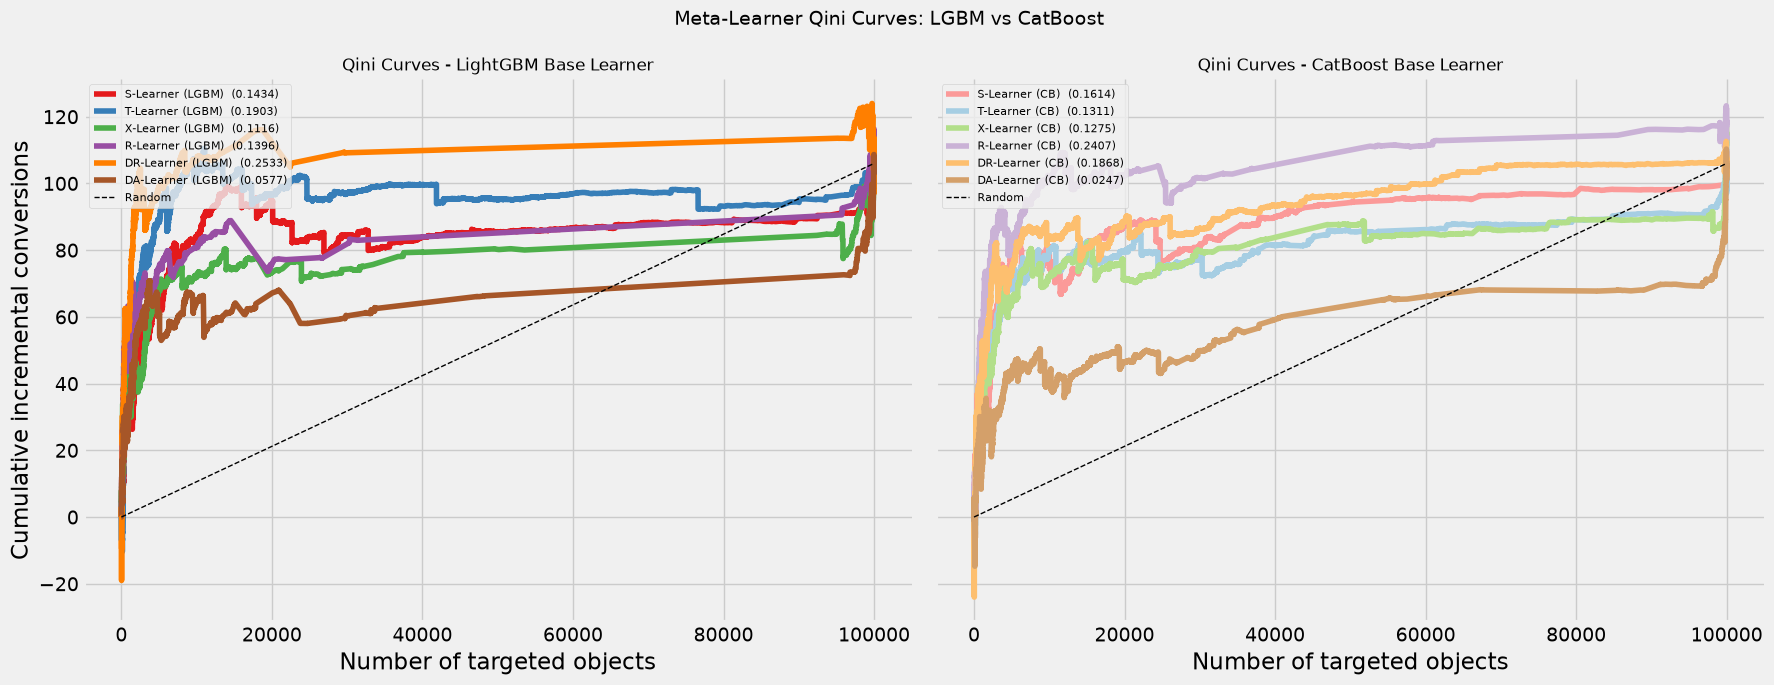

In [21]:
# Draw the Qini curves by hand with sklift.metrics.qini_curve. Calling
# plot_qini_curve several times on one axis breaks on matplotlib >= 3.7, so we
# plot each curve directly and add one random-baseline line.
LGBM_COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']
CB_COLORS   = ['#fb9a99', '#a6cee3', '#b2df8a', '#cab2d6', '#fdbf6f', '#d4a06a']

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, base, colors, title in [
    (axes[0], 'LGBM', LGBM_COLORS, 'LightGBM Base Learner'),
    (axes[1], 'CB',   CB_COLORS,   'CatBoost Base Learner'),
]:
    subset = [(n, s) for n, s in qini_curves.items() if f'({base})' in n]
    end = None
    for (name, scores), color in zip(subset, colors):
        x, y = qini_curve(y_test, np.asarray(scores).flatten(), treat_test)
        ax.plot(x, y, label=f'{name}  ({results[name]["Qini"]:.4f})', color=color)
        end = (x[-1], y[-1])
    if end is not None:
        ax.plot([0, end[0]], [0, end[1]], 'k--', lw=1, label='Random')
    ax.set_title(f'Qini Curves - {title}', fontsize=12)
    ax.set_xlabel('Number of targeted objects')
    ax.legend(loc='upper left', fontsize=8)

axes[0].set_ylabel('Cumulative incremental conversions')
plt.suptitle('Meta-Learner Qini Curves: LGBM vs CatBoost', fontsize=14)
plt.tight_layout()
plt.savefig('meta_learners_qini_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Actual uplift by score decile

Ranking-calibration check: sort the test set by $\hat\tau$, bin into 10 deciles (decile 0 = highest predicted uplift), compute the actual $\bar Y_{T=1} - \bar Y_{T=0}$ per decile. Informative rankings decrease monotonically. In-decile differences are unbiased only because assignment is randomized, and bars carry large sampling error at a ~0.2% conversion rate - read shapes, not point values.

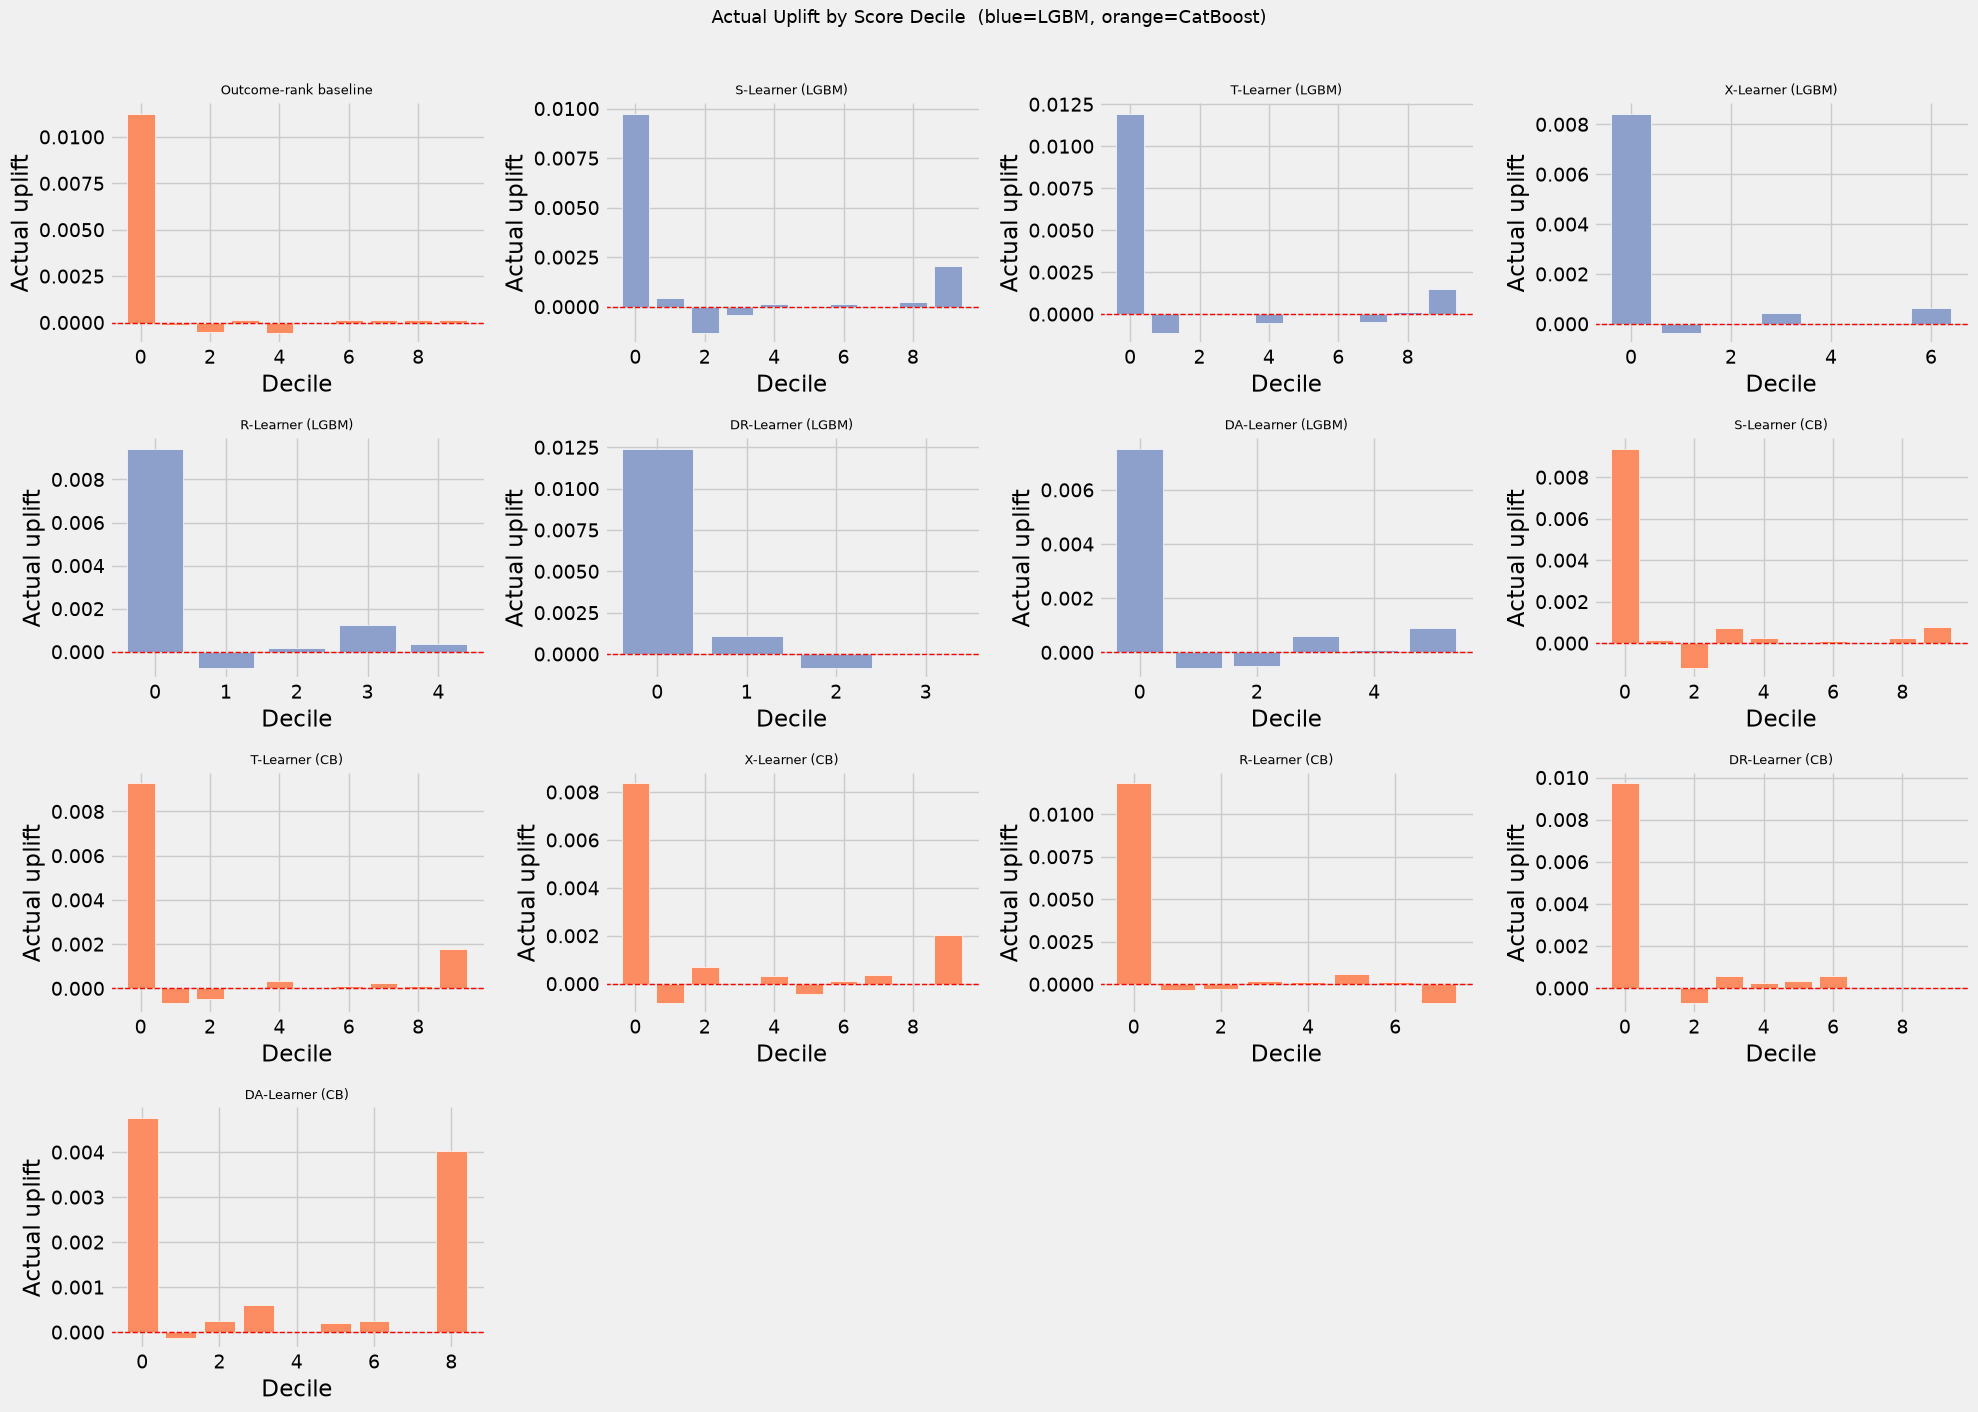

In [22]:
def uplift_by_decile(y, scores, treatment, n_deciles=10):
    df = pd.DataFrame({'y': y, 'treat': treatment, 'score': scores})
    df['decile'] = pd.qcut(df['score'], q=n_deciles, labels=False, duplicates='drop')
    df['decile'] = df['decile'].max() - df['decile']
    return df.groupby('decile').apply(
        lambda g: g.loc[g.treat==1,'y'].mean() - g.loc[g.treat==0,'y'].mean()
        if (g.treat==1).sum()>0 and (g.treat==0).sum()>0 else np.nan
    ).rename('uplift')


n_models = len(qini_curves)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*3.5), sharey=False)
axes = axes.flatten()

for i, (name, scores) in enumerate(qini_curves.items()):
    deciles = uplift_by_decile(y_test, scores, treat_test)
    color = '#8da0cb' if '(LGBM)' in name else '#fc8d62'
    axes[i].bar(deciles.index, deciles.values, color=color, edgecolor='white')
    axes[i].axhline(0, color='red', lw=1, linestyle='--')
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('Decile')
    axes[i].set_ylabel('Actual uplift')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Actual Uplift by Score Decile  (blue=LGBM, orange=CatBoost)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('meta_learners_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

## Overall Qini and Uplift@20% summary

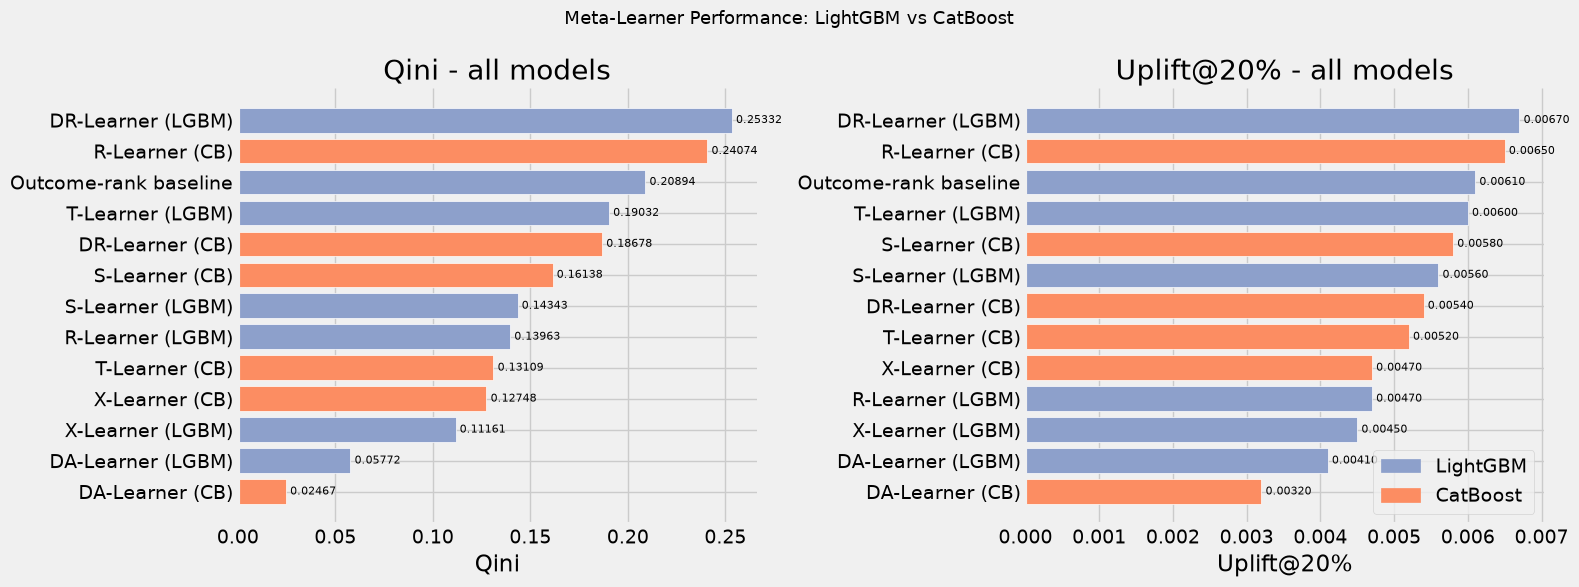

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ['Qini', 'Uplift@20%']):
    vals = df_results[metric].sort_values(ascending=True)
    bar_colors = ['#fc8d62' if '(CB)' in n else '#8da0cb' for n in vals.index]
    bars = ax.barh(vals.index, vals.values, color=bar_colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.5f', padding=3, fontsize=8)
    ax.set_title(f'{metric} - all models')
    ax.set_xlabel(metric)

# Legend
import matplotlib.patches as mpatches
leg = [
    mpatches.Patch(color='#8da0cb', label='LightGBM'),
    mpatches.Patch(color='#fc8d62', label='CatBoost'),
]
axes[1].legend(handles=leg, loc='lower right')

plt.suptitle('Meta-Learner Performance: LightGBM vs CatBoost', fontsize=13)
plt.tight_layout()
plt.savefig('meta_learners_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import os, pickle
os.makedirs('artifacts', exist_ok=True)
with open('artifacts/01_meta_learners.pkl', 'wb') as f:
    pickle.dump({'results': results, 'qini_curves': qini_curves,
                 'y_test': y_test, 't_test': treat_test}, f)
print('Saved artifacts/01_meta_learners.pkl')

Saved artifacts/01_meta_learners.pkl


## Takeaways

The textbook ordering DR > R > X > T > S does not hold on this run: within LGBM the Qini order is DR > T > S > R > X, within CatBoost R > DR > S > T > X, and DA trails everywhere. Only two of twelve uplift models beat the outcome-rank baseline - a strong response model is a hard bar on small-ATE data. Select models via the bootstrap-CI tiers in [06_benchmark.ipynb](06_benchmark.ipynb), not single-split point rankings.

Next: [02_tree_methods.ipynb](02_tree_methods.ipynb) - Uplift Random Forest, Causal Forest (GRF), Honest Causal Tree.